# 07 Integration

This notebook performs the final **multi-omics integration** step for the
`multiomics-perturbation-target-discovery` project.

## Goal

Combine evidence from:

1. **Disease–perturbation anticorrelation** (`04_anticorrelation.ipynb`)
2. **Single-cell validation** (`05_single_cell_fixed.ipynb`)
3. **Proteomics validation** (`06_proteomics_fixed_v2.ipynb`)

to produce a final integrated ranking of therapeutic perturbations and candidate targets.

## Biological interpretation

The overall project logic is:

- disease transcriptomics defines dysregulated pathways
- perturbation signatures are tested for pathway reversal
- single-cell data checks whether candidate targets are present in relevant cell populations
- proteomics data checks whether candidate targets are supported at the protein level

A strong candidate is therefore one that:

- reverses disease-associated pathway activity
- is biologically plausible for the disease context
- is supported across orthogonal evidence layers when available

For the current ulcerative colitis use case, plausible mechanisms include:

- **glucocorticoid-mediated reversal** of inflammatory programs
- **JAK inhibition** of cytokine and interferon signaling


## Expected inputs

### Required
- `results/tables/final_anticorrelation_ranking.tsv`

### Optional downstream validation outputs
- `results/tables/final_single_cell_target_validation.tsv`
- `results/tables/final_single_cell_perturbation_validation.tsv`
- `results/tables/final_proteomics_target_validation.tsv`
- `results/tables/final_proteomics_perturbation_validation.tsv`

If single-cell or proteomics validation is absent, the notebook will still run and produce an
integration based on the available evidence.

## Main outputs

### Tables
- `results/tables/final_integrated_target_ranking.tsv`
- `results/tables/final_integrated_perturbation_ranking.tsv`

### Figures
- `results/figures/integration_final_perturbation_ranking_barplot.png`
- `results/figures/integration_evidence_component_heatmap.png`
- `results/figures/integration_target_evidence_heatmap.png`
- `results/figures/integration_summary_bubbleplot.png`


In [13]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [14]:
PROJECT_ROOT = Path("..").resolve()

RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

anticorr_file = RESULTS_TABLES / "final_anticorrelation_ranking.tsv"

sc_target_file = RESULTS_TABLES / "final_single_cell_target_validation.tsv"
sc_pert_file = RESULTS_TABLES / "final_single_cell_perturbation_validation.tsv"

prot_target_file = RESULTS_TABLES / "final_proteomics_target_validation.tsv"
prot_pert_file = RESULTS_TABLES / "final_proteomics_perturbation_validation.tsv"

anticorr_file, sc_target_file, sc_pert_file, prot_target_file, prot_pert_file


(PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_anticorrelation_ranking.tsv'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_single_cell_target_validation.tsv'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_single_cell_perturbation_validation.tsv'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_proteomics_target_validation.tsv'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_proteomics_perturbation_validation.tsv'))

## Design principles

This integration notebook follows a few rules:

1. **Do not invent evidence.** Missing evidence contributes zero, not artificial support.
2. **Keep reversal primary.** Anticorrelation remains the main ranking backbone.
3. **Use validation layers as modifiers.** Single-cell and proteomics add confidence when present.
4. **Stay interpretable.** Every final score can be broken into component contributions.


In [15]:
def read_tsv_if_present(path):
    if not path.exists():
        return pd.DataFrame()
    try:
        df = pd.read_csv(path, sep="\t")
        return df
    except Exception as e:
        print(f"Could not read {path.name}: {e}")
        return pd.DataFrame()

def minmax_scale(series):
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(np.nan, index=series.index, dtype=float)

    valid = s.notna()
    if valid.sum() == 0:
        return out.fillna(0.0)

    s_valid = s[valid]
    smin = s_valid.min()
    smax = s_valid.max()

    if pd.isna(smin) or pd.isna(smax):
        return out.fillna(0.0)

    if smin == smax:
        return pd.Series(0.0, index=series.index, dtype=float)

    out.loc[valid] = (s_valid - smin) / (smax - smin)
    return out.fillna(0.0)

def normalize_gene_symbol_series(s):
    return (
        s.astype(str)
         .str.strip()
         .str.upper()
         .replace({"": np.nan, "NAN": np.nan, "NONE": np.nan})
    )

def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


In [16]:
def load_anticorrelation(path):
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}\n"
            "Run 04_anticorrelation.ipynb first."
        )
    df = pd.read_csv(path, sep="\t")

    required = ["perturbation_id", "perturbation_name"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Anticorrelation ranking missing required columns: {missing}")

    if "anticorrelation_score" not in df.columns:
        raise KeyError("Anticorrelation ranking must contain 'anticorrelation_score'.")

    # More negative anticorrelation_score = better reversal
    df["anticorrelation_component"] = minmax_scale(-pd.to_numeric(df["anticorrelation_score"], errors="coerce"))

    for col in ["pearson_corr", "spearman_corr", "n_shared_pathways"]:
        if col not in df.columns:
            df[col] = np.nan

    return df.copy()

def load_pert_validation(path, value_candidates, prefix):
    df = read_tsv_if_present(path)
    if df.empty:
        return df

    required = ["perturbation_id", "perturbation_name"]
    if any(c not in df.columns for c in required):
        print(f"{path.name}: missing perturbation identifiers; skipping.")
        return pd.DataFrame()

    value_col = first_existing_column(df, value_candidates)
    if value_col is None:
        print(f"{path.name}: no recognized score column among {value_candidates}; skipping.")
        return pd.DataFrame()

    out = df[["perturbation_id", "perturbation_name", value_col]].copy()
    out = out.rename(columns={value_col: f"{prefix}_raw"})
    out[f"{prefix}_raw"] = pd.to_numeric(out[f"{prefix}_raw"], errors="coerce")
    out[f"{prefix}_component"] = minmax_scale(out[f"{prefix}_raw"])
    return out

anticorr_df = load_anticorrelation(anticorr_file)
sc_pert_df = load_pert_validation(
    sc_pert_file,
    ["integrated_validation_score", "single_cell_support_score", "mean_single_cell_support"],
    "single_cell"
)
prot_pert_df = load_pert_validation(
    prot_pert_file,
    ["integrated_validation_score", "mean_proteomics_support", "proteomics_support_score"],
    "proteomics"
)

print("Anticorrelation rows:", anticorr_df.shape)
print("Single-cell perturbation rows:", sc_pert_df.shape)
print("Proteomics perturbation rows:", prot_pert_df.shape)

display(anticorr_df.head())
display(sc_pert_df.head())
display(prot_pert_df.head())


final_single_cell_perturbation_validation.tsv: no recognized score column among ['integrated_validation_score', 'single_cell_support_score', 'mean_single_cell_support']; skipping.
Anticorrelation rows: (4, 24)
Single-cell perturbation rows: (0, 0)
Proteomics perturbation rows: (4, 4)


,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,n_shared_pathways,pearson_corr,pearson_pvalue,spearman_corr,...,neg_disease_reversal_fraction,weighted_reversal_strength,normalized_reversal_strength,mean_abs_disease_NES,mean_abs_perturbation_NES,reliability_factor,anticorrelation_score,confidence_flag,valid_for_ranking,anticorrelation_component
0,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,0.500000,66.444880,19.984733,1.881248,1.767327,0.333333,0.487825,low,True,0.000000
1,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,7,-0.278907,0.544713,-0.142857,...,0.333333,-20.391042,-6.838121,1.843658,1.617418,0.466667,-0.159091,low,True,0.194347
2,drug_004,tofacitinib,NaN,NaN,NaN,curated_public_signature,6,0.477599,0.338072,0.485714,...,0.000000,-349.695624,-106.031381,1.859704,1.773421,0.400000,-2.840847,low,True,1.000000
3,drug_005,ruxolitinib,NaN,NaN,NaN,curated_public_signature,4,0.593478,0.406522,0.800000,...,0.000000,-290.299429,-97.845963,1.910230,1.553165,0.266667,-1.751798,insufficient_shared_pathways,False,0.672828


""


,perturbation_id,perturbation_name,proteomics_raw,proteomics_component
0,drug_004,tofacitinib,0.837357,1.000000
1,drug_001,dexamethasone,0.416608,0.217003
2,drug_005,ruxolitinib,0.403697,0.192975
3,drug_002,budesonide,0.300000,0.000000


## Perturbation-level integration

The final perturbation score is designed to preserve the importance of transcriptomic reversal while allowing orthogonal validation layers to strengthen confidence.

### Default weighting

- **0.70** anticorrelation component
- **0.15** single-cell component
- **0.15** proteomics component

If a validation layer is absent, its component remains zero. This makes the notebook robust and honest.


In [17]:
perturbation_integrated = anticorr_df.copy()

if not sc_pert_df.empty:
    perturbation_integrated = perturbation_integrated.merge(
        sc_pert_df,
        on=["perturbation_id", "perturbation_name"],
        how="left"
    )
else:
    perturbation_integrated["single_cell_raw"] = np.nan
    perturbation_integrated["single_cell_component"] = 0.0

if not prot_pert_df.empty:
    perturbation_integrated = perturbation_integrated.merge(
        prot_pert_df,
        on=["perturbation_id", "perturbation_name"],
        how="left"
    )
else:
    perturbation_integrated["proteomics_raw"] = np.nan
    perturbation_integrated["proteomics_component"] = 0.0

for col in ["single_cell_component", "proteomics_component"]:
    if col not in perturbation_integrated.columns:
        perturbation_integrated[col] = 0.0
    perturbation_integrated[col] = pd.to_numeric(perturbation_integrated[col], errors="coerce").fillna(0.0)

perturbation_integrated["final_integrated_score"] = (
    0.70 * perturbation_integrated["anticorrelation_component"] +
    0.15 * perturbation_integrated["single_cell_component"] +
    0.15 * perturbation_integrated["proteomics_component"]
)

perturbation_integrated["evidence_layers_available"] = (
    1
    + (perturbation_integrated["single_cell_component"] > 0).astype(int)
    + (perturbation_integrated["proteomics_component"] > 0).astype(int)
)

perturbation_integrated["integration_confidence"] = np.select(
    [
        (perturbation_integrated["evidence_layers_available"] >= 3) &
        (perturbation_integrated["final_integrated_score"] >= 0.67),

        (perturbation_integrated["evidence_layers_available"] >= 2) &
        (perturbation_integrated["final_integrated_score"] >= 0.34)
    ],
    [
        "high",
        "moderate"
    ],
    default="baseline"
)

perturbation_integrated = perturbation_integrated.sort_values(
    ["final_integrated_score", "anticorrelation_component", "perturbation_name"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(perturbation_integrated)


,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,n_shared_pathways,pearson_corr,pearson_pvalue,spearman_corr,...,confidence_flag,valid_for_ranking,anticorrelation_component,single_cell_raw,single_cell_component,proteomics_raw,proteomics_component,final_integrated_score,evidence_layers_available,integration_confidence
0,drug_004,tofacitinib,NaN,NaN,NaN,curated_public_signature,6,0.477599,0.338072,0.485714,...,low,True,1.000000,NaN,0.0,0.837357,1.000000,0.850000,2,moderate
1,drug_005,ruxolitinib,NaN,NaN,NaN,curated_public_signature,4,0.593478,0.406522,0.800000,...,insufficient_shared_pathways,False,0.672828,NaN,0.0,0.403697,0.192975,0.499926,2,moderate
2,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,7,-0.278907,0.544713,-0.142857,...,low,True,0.194347,NaN,0.0,0.416608,0.217003,0.168593,2,baseline
3,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,low,True,0.000000,NaN,0.0,0.300000,0.000000,0.000000,1,baseline


## Target-level integration

Target-level integration combines optional single-cell and proteomics support for the mapped targets of each perturbation.

This layer is useful for explaining *why* a perturbation is plausible mechanistically.


In [18]:
def load_target_validation(path, value_candidates, prefix):
    df = read_tsv_if_present(path)
    if df.empty:
        return df

    pert_cols = ["perturbation_id", "perturbation_name"]
    gene_col = first_existing_column(df, ["gene_symbol", "target_gene"])
    value_col = first_existing_column(df, value_candidates)

    if any(c not in df.columns for c in pert_cols) or gene_col is None or value_col is None:
        print(f"{path.name}: missing target-level required columns; skipping.")
        return pd.DataFrame()

    out = df[pert_cols + [gene_col, value_col]].copy()
    out = out.rename(columns={
        gene_col: "gene_symbol",
        value_col: f"{prefix}_raw"
    })
    out["gene_symbol"] = normalize_gene_symbol_series(out["gene_symbol"])
    out[f"{prefix}_raw"] = pd.to_numeric(out[f"{prefix}_raw"], errors="coerce")
    out[f"{prefix}_component"] = minmax_scale(out[f"{prefix}_raw"])
    return out

sc_target_df = load_target_validation(
    sc_target_file,
    ["single_cell_support_score", "proteomics_support_score", "integrated_validation_score"],
    "single_cell"
)
prot_target_df = load_target_validation(
    prot_target_file,
    ["proteomics_support_score", "integrated_validation_score"],
    "proteomics"
)

print("Single-cell target rows:", sc_target_df.shape)
print("Proteomics target rows:", prot_target_df.shape)

display(sc_target_df.head())
display(prot_target_df.head())


Single-cell target rows: (77, 5)
Proteomics target rows: (11, 5)


,perturbation_id,perturbation_name,gene_symbol,single_cell_raw,single_cell_component
0,drug_002,budesonide,NR3C1,0.108049,0.147549
1,drug_002,budesonide,NR3C1,0.095655,0.130624
2,drug_002,budesonide,NR3C1,0.016273,0.022222
3,drug_002,budesonide,NR3C1,0.039324,0.053700
4,drug_002,budesonide,NR3C1,0.238089,0.325128


,perturbation_id,perturbation_name,gene_symbol,proteomics_raw,proteomics_component
0,drug_002,budesonide,FKBP5,0.600000,1.000000
1,drug_001,dexamethasone,FKBP5,0.600000,1.000000
2,drug_004,tofacitinib,TYK2,0.416189,0.693649
3,drug_004,tofacitinib,JAK1,0.364813,0.608022
4,drug_005,ruxolitinib,JAK1,0.364813,0.608022


In [19]:
# build target universe from available validation tables
target_frames = []

if not sc_target_df.empty:
    target_frames.append(sc_target_df[["perturbation_id", "perturbation_name", "gene_symbol"]])

if not prot_target_df.empty:
    target_frames.append(prot_target_df[["perturbation_id", "perturbation_name", "gene_symbol"]])

# fallback target mapping if no target validation files exist
if len(target_frames) == 0:
    mapping = {
        "DEXAMETHASONE": ["NR3C1", "FKBP5", "TSC22D3"],
        "BUDESONIDE": ["NR3C1", "FKBP5", "TSC22D3"],
        "TOFACITINIB": ["JAK1", "JAK3", "TYK2"],
        "RUXOLITINIB": ["JAK1", "JAK2"],
    }
    rows = []
    for _, row in anticorr_df.iterrows():
        genes = mapping.get(str(row["perturbation_name"]).strip().upper(), [np.nan])
        for g in genes:
            rows.append({
                "perturbation_id": row["perturbation_id"],
                "perturbation_name": row["perturbation_name"],
                "gene_symbol": g
            })
    target_base = pd.DataFrame(rows)
else:
    target_base = pd.concat(target_frames, ignore_index=True).drop_duplicates()

target_base["gene_symbol"] = normalize_gene_symbol_series(target_base["gene_symbol"])
target_base = target_base.dropna(subset=["gene_symbol"]).reset_index(drop=True)

if not sc_target_df.empty:
    target_integrated = target_base.merge(
        sc_target_df,
        on=["perturbation_id", "perturbation_name", "gene_symbol"],
        how="left"
    )
else:
    target_integrated = target_base.copy()
    target_integrated["single_cell_raw"] = np.nan
    target_integrated["single_cell_component"] = 0.0

if not prot_target_df.empty:
    target_integrated = target_integrated.merge(
        prot_target_df,
        on=["perturbation_id", "perturbation_name", "gene_symbol"],
        how="left"
    )
else:
    target_integrated["proteomics_raw"] = np.nan
    target_integrated["proteomics_component"] = 0.0

for col in ["single_cell_component", "proteomics_component"]:
    if col not in target_integrated.columns:
        target_integrated[col] = 0.0
    target_integrated[col] = pd.to_numeric(target_integrated[col], errors="coerce").fillna(0.0)

target_integrated["target_integrated_score"] = (
    0.50 * target_integrated["single_cell_component"] +
    0.50 * target_integrated["proteomics_component"]
)

target_integrated["target_validation_flag"] = np.select(
    [
        target_integrated["target_integrated_score"] >= 0.67,
        target_integrated["target_integrated_score"] >= 0.34
    ],
    [
        "strong",
        "moderate"
    ],
    default="limited"
)

target_integrated = target_integrated.sort_values(
    ["target_integrated_score", "perturbation_name", "gene_symbol"],
    ascending=[False, True, True]
).reset_index(drop=True)

display(target_integrated.head(25))


,perturbation_id,perturbation_name,gene_symbol,single_cell_raw,single_cell_component,proteomics_raw,proteomics_component,target_integrated_score,target_validation_flag
0,drug_002,budesonide,TSC22D3,0.732294,1.000000,0.320133,0.533554,0.766777,strong
1,drug_001,dexamethasone,TSC22D3,0.732294,1.000000,0.320133,0.533554,0.766777,strong
2,drug_002,budesonide,FKBP5,0.273531,0.373526,0.600000,1.000000,0.686763,strong
3,drug_001,dexamethasone,FKBP5,0.273531,0.373526,0.600000,1.000000,0.686763,strong
4,drug_002,budesonide,TSC22D3,0.522959,0.714138,0.320133,0.533554,0.623846,moderate
5,drug_001,dexamethasone,TSC22D3,0.522959,0.714138,0.320133,0.533554,0.623846,moderate
6,drug_002,budesonide,TSC22D3,0.514689,0.702844,0.320133,0.533554,0.618199,moderate
7,drug_001,dexamethasone,TSC22D3,0.514689,0.702844,0.320133,0.533554,0.618199,moderate
8,drug_002,budesonide,TSC22D3,0.424582,0.579797,0.320133,0.533554,0.556676,moderate
9,drug_001,dexamethasone,TSC22D3,0.424582,0.579797,0.320133,0.533554,0.556676,moderate


## Final output interpretation

### Final perturbation ranking

This is the main decision-level output of the project.

### Final target ranking

This is the main mechanism-level output of the project.

Together they answer two complementary questions:

1. **Which perturbations best reverse disease biology?**
2. **Which target genes are most supported across validation layers?**


In [20]:
pert_out = RESULTS_TABLES / "final_integrated_perturbation_ranking.tsv"
target_out = RESULTS_TABLES / "final_integrated_target_ranking.tsv"

perturbation_integrated.to_csv(pert_out, sep="\t", index=False)
target_integrated.to_csv(target_out, sep="\t", index=False)

print("Saved:", pert_out)
print("Saved:", target_out)


Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_integrated_perturbation_ranking.tsv
Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_integrated_target_ranking.tsv


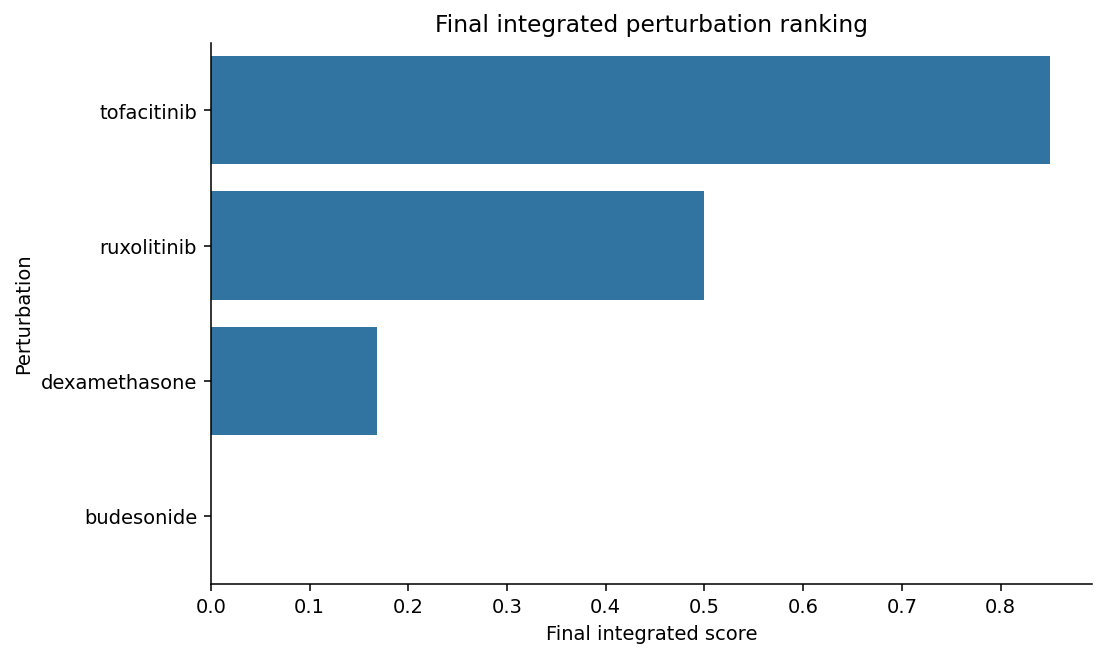

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/integration_final_perturbation_ranking_barplot.png


In [21]:
# Figure 1: final perturbation ranking
plot_df = perturbation_integrated.copy()

plt.figure(figsize=(8, 4.8))
sns.barplot(data=plot_df, x="final_integrated_score", y="perturbation_name")
plt.xlabel("Final integrated score")
plt.ylabel("Perturbation")
plt.title("Final integrated perturbation ranking")
plt.tight_layout()
out = RESULTS_FIGURES / "integration_final_perturbation_ranking_barplot.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print("Saved:", out)


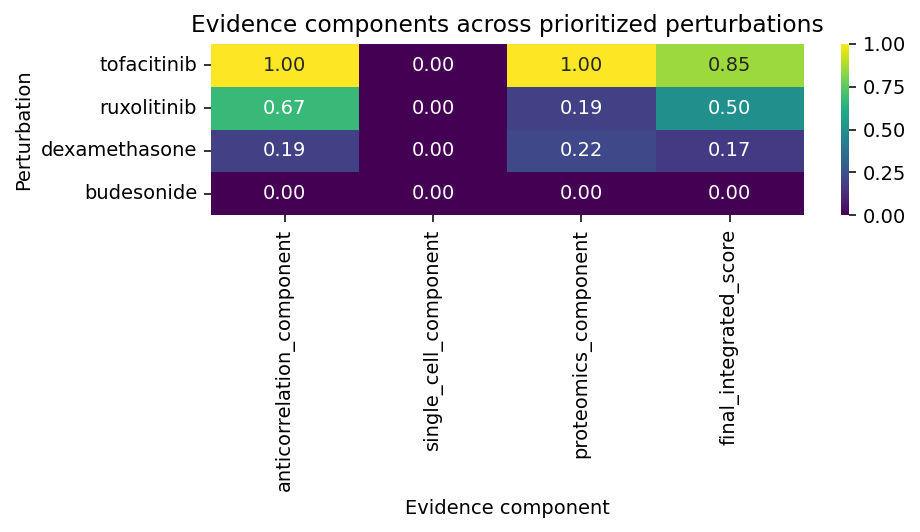

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/integration_evidence_component_heatmap.png


In [22]:
# Figure 2: evidence component heatmap
heat_df = perturbation_integrated.set_index("perturbation_name")[
    ["anticorrelation_component", "single_cell_component", "proteomics_component", "final_integrated_score"]
]

plt.figure(figsize=(7, max(3, 0.6 * heat_df.shape[0] + 1.5)))
sns.heatmap(heat_df, cmap="viridis", annot=True, fmt=".2f")
plt.title("Evidence components across prioritized perturbations")
plt.xlabel("Evidence component")
plt.ylabel("Perturbation")
plt.tight_layout()
out = RESULTS_FIGURES / "integration_evidence_component_heatmap.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print("Saved:", out)


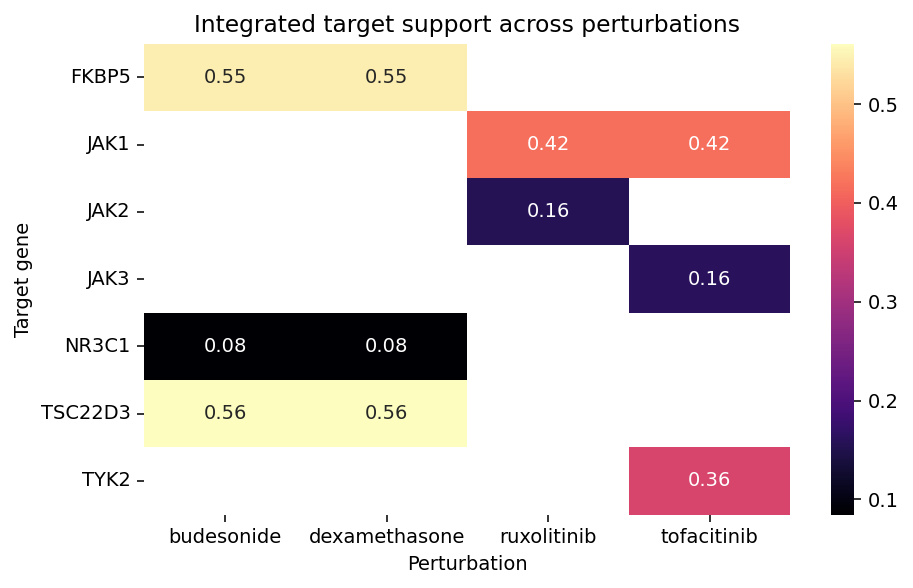

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/integration_target_evidence_heatmap.png


In [23]:
# Figure 3: target evidence heatmap
if not target_integrated.empty:
    heat_df = target_integrated.pivot_table(
        index="gene_symbol",
        columns="perturbation_name",
        values="target_integrated_score",
        aggfunc="mean"
    )
    if heat_df.shape[0] > 0 and heat_df.shape[1] > 0:
        plt.figure(figsize=(7, max(3, 0.4 * heat_df.shape[0] + 1.5)))
        sns.heatmap(heat_df, cmap="magma", annot=True, fmt=".2f")
        plt.title("Integrated target support across perturbations")
        plt.xlabel("Perturbation")
        plt.ylabel("Target gene")
        plt.tight_layout()
        out = RESULTS_FIGURES / "integration_target_evidence_heatmap.png"
        plt.savefig(out, bbox_inches="tight")
        plt.show()
        print("Saved:", out)
    else:
        print("Skipping target heatmap: insufficient dimensions.")
else:
    print("Skipping target heatmap: no target rows available.")


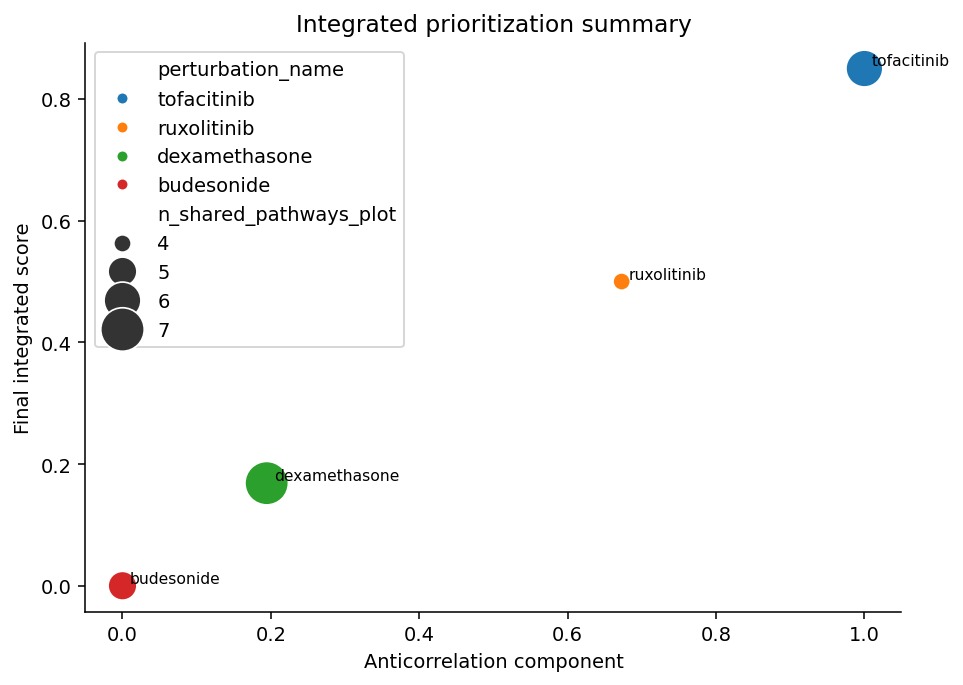

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/integration_summary_bubbleplot.png


In [24]:
# Figure 4: summary bubble plot
plot_df = perturbation_integrated.copy()
plot_df["n_shared_pathways_plot"] = pd.to_numeric(plot_df["n_shared_pathways"], errors="coerce").fillna(1)
plot_df["pearson_corr_plot"] = pd.to_numeric(plot_df["pearson_corr"], errors="coerce")

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=plot_df,
    x="anticorrelation_component",
    y="final_integrated_score",
    size="n_shared_pathways_plot",
    sizes=(80, 500),
    hue="perturbation_name"
)
for _, row in plot_df.iterrows():
    plt.text(
        row["anticorrelation_component"] + 0.01,
        row["final_integrated_score"] + 0.005,
        str(row["perturbation_name"]),
        fontsize=8
    )
plt.xlabel("Anticorrelation component")
plt.ylabel("Final integrated score")
plt.title("Integrated prioritization summary")
plt.tight_layout()
out = RESULTS_FIGURES / "integration_summary_bubbleplot.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print("Saved:", out)


## Suggested narrative for the repository

A strong final candidate is one that:

- shows strong pathway-level reversal of disease biology
- remains plausible when examined at the target level
- gains support from orthogonal evidence layers when available

In this project, the transcriptomic anticorrelation step defines the primary therapeutic hypothesis,
while single-cell and proteomics layers provide additional biological grounding.

This structure is especially useful in real translational settings, where not all omics layers are always available,
but evidence still needs to be integrated reproducibly and transparently.


## Recommended next extensions

- add real drug-target mappings from DrugBank / ChEMBL / DGIdb
- integrate causal network or pathway-graph evidence
- incorporate GWAS or genetics-based support
- include literature-derived evidence weights
- extend from candidate perturbations to direct target nomination
